In [180]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# keras contains the tensorflow package, often used for fitting NNets
import keras
from keras.datasets import mnist
from keras.models import Model
from keras.layers import Dense, Input, Dropout, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D, Flatten
from keras.optimizers import SGD, Adam
from keras.losses import binary_crossentropy

import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [181]:
cat_data = np.load('data/cat_images.npy') # make sure these point to the correct directory
dog_data = np.load('data/dog_images.npy')

In [182]:
print(cat_data.shape)
print(dog_data.shape)

(211, 540, 499)
(305, 540, 499)


In [183]:
# our images are 540x499 pixels
img_rows, img_cols = 540, 499

# create label vector (we’ll say 1 = Cat, 0 = Dog)
y = np.concatenate((np.ones(cat_data.shape[0]), np.zeros(dog_data.shape[0])))

# put the data together
pet_data = np.concatenate((cat_data, dog_data))

# split the data into training and test
# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
pet_data, y, test_size=0.25, random_state=42
)

# Normalize image data
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape to add channel dimension for Keras
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

In [184]:
x_train.shape

(387, 540, 499, 1)

In [185]:
# check out the test output
y_test

array([0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1.,
       1., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1.,
       1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 0., 0., 1., 0., 0., 0., 1.,
       0., 0., 1., 0., 1., 1., 0., 0., 1., 0., 1., 1., 1., 0., 0., 1., 0.,
       0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 1.,
       0., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0.,
       0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0.,
       1., 0., 1., 1., 1., 0., 1., 0., 0., 1.])

In [186]:
# grab our image plotter from the other notebook
def plot_img(x, im_shape):
    plt.imshow(x.reshape(im_shape), cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.gcf().set_size_inches(4, 4)

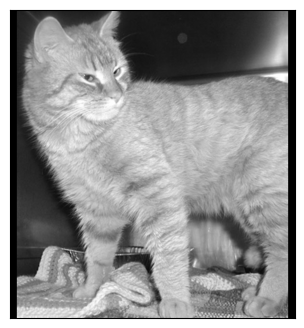

In [187]:
plot_img(x_test[x_test.shape[0]-1], im_shape=(540, 499))

In [188]:
inpx = Input(shape=(540, 499, 1))

x = Conv2D(16, (3,3), activation='relu', padding='same')(inpx)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.35)(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.35)(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.35)(x)

x = Flatten()(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(32, activation='relu')(x)

out = Dense(1, activation='sigmoid')(x)

In [189]:
model = Model([inpx], out)
model.compile(optimizer=Adam(),
              loss=binary_crossentropy,
              metrics=['accuracy'])

In [190]:
history = model.fit(x_train, y_train, epochs=7, batch_size=8, validation_data=(x_test, y_test))

Epoch 1/7
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 174ms/step - accuracy: 0.5711 - loss: 18.8778 - val_accuracy: 0.4496 - val_loss: 3.5991
Epoch 2/7
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5452 - loss: 7.3387 - val_accuracy: 0.4419 - val_loss: 44.2368
Epoch 3/7
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5401 - loss: 1.6408 - val_accuracy: 0.4419 - val_loss: 25.2968
Epoch 4/7
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.4884 - loss: 1.0233 - val_accuracy: 0.4651 - val_loss: 10.6723
Epoch 5/7
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.4910 - loss: 0.6769 - val_accuracy: 0.4574 - val_loss: 8.2329
Epoch 6/7
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5995 - loss: 0.7297 - val_accuracy: 0.4496 - val_loss: 5.5804
Epoch 7/7
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5891 - loss: 0.6949 - val_accuracy: 0.4574 - val_loss: 5.0972


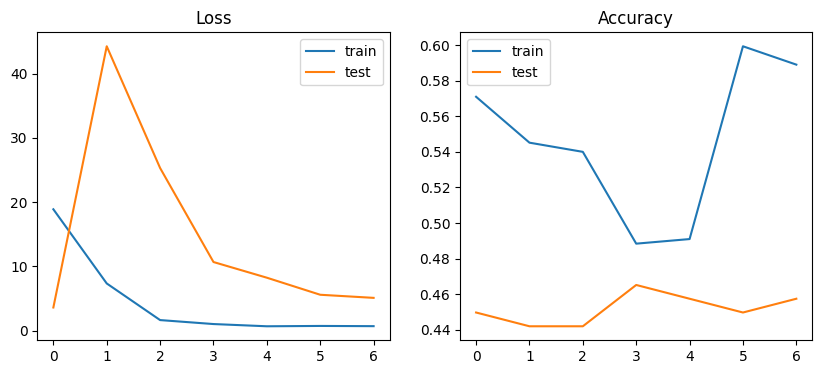

In [191]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.title('Accuracy')
plt.legend()
plt.show()

In [176]:
# checking test set performance
score = model.evaluate(x_test, y_test, verbose=0)
print('loss=', score[0])
print('accuracy=', score[1])

loss= 3.1515119075775146
accuracy= 0.4806201457977295


I did a pretty terrible job. Its basically half and half, so didn't learn much. I don't think this does a good job of finding out whether a picture is a dog or a cat.

In [177]:
# Seems good, but check HOW it's good
import pandas as pd

preds = model.predict(x_test)
y_true = np.asarray(y_test).ravel().astype(int)
y_pred = (preds.reshape(-1) >= 0.5).astype(int)
tbl = pd.crosstab(y_pred, y_true, rownames=['Predicted'], colnames=['Actual'])
print(tbl)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step
Actual      0   1
Predicted        
0           8   3
1          64  54


In [178]:
# print kernel weights of the convolutional layer
conv_weights = model.layers[1].get_weights()[0]
W = conv_weights[:,:,0,0]
print("Convolutional kernel weights:")
print(W)

Convolutional kernel weights:
[[ 0.11845005  0.11364334 -0.1265223 ]
 [-0.12466034  0.05123786  0.19235478]
 [-0.15874745 -0.01453609  0.00574521]]


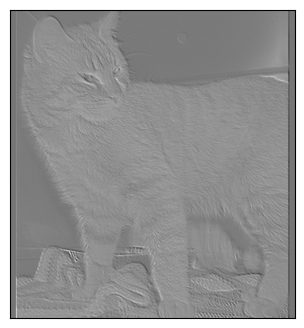

In [192]:
# grab the convMat function from cnn.ipynb to do the forward pass and then visualize what the recovered kernel is doing
def convMat(X, W):
    k, _ = W.shape
    p, q = X.shape  # height, width

    out_h = p - k + 1
    out_w = q - k + 1
    G = np.zeros((out_h, out_w))

    for m in range(out_h):
        for n in range(out_w):
            submatrix = X[m:m+k, n:n+k]
            G[m, n] = np.sum(W * submatrix)

    return G

G = convMat(x_test[x_test.shape[0]-1][:,:,0], W)

# image isn't changing a lot in the convolutional layer
plot_img(G, G.shape)

In [193]:
import numpy as np
from PIL import Image, ImageOps

def convert_image_to_grayscale_with_padding(image_path, target_width=None, target_height=None):
    """
    Converts a single .jpg image to grayscale and optionally pads it to the target dimensions.

    Args:
        image_path (str): Path to the input .jpg image.
        target_width (int, optional): Target width for padding. If None, keeps the original width.
        target_height (int, optional): Target height for padding. If None, keeps the original height.

    Returns:
        np.ndarray: Grayscale image as a numpy array, with optional padding applied.
    """
    # Open the image
    with Image.open(image_path) as img:
        # Convert to grayscale
        grayscale_img = img.convert('L')
        
        # If target dimensions are provided, pad the image
        if target_width and target_height:
            padded_img = ImageOps.pad(grayscale_img, (target_width, target_height), color=0)
        else:
            padded_img = grayscale_img
        
        # Convert the image to a numpy array
        grayscale_array = np.array(padded_img)

    return grayscale_array

In [ ]:
img_arr = convert_image_to_grayscale_with_padding(
    "data/image.jpg",
    target_width=499,
    target_height=540
)

x = img_arr.astype("float32") / 255.0
x = x[..., np.newaxis]
x = x[np.newaxis, ...]

pred = model.predict(x)[0][0]
print("prob(cat) =", pred)
print("label =", "cat" if pred >= 0.5 else "dog")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step
prob(cat) = 0.99999976
label = cat


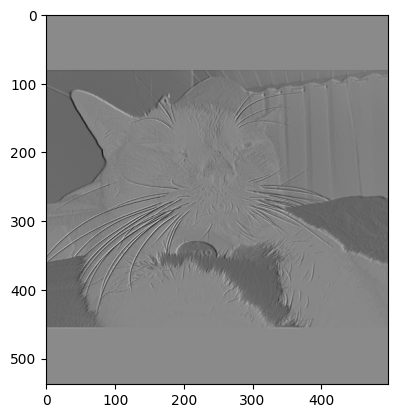

In [ ]:
W, b = model.layers[1].get_weights()
kernel = W[:, :, 0, 0]

img_arr = convert_image_to_grayscale_with_padding("data/image.jpg", target_width=499, target_height=540)
x = img_arr.astype("float32") / 255.0

G = convMat(x, kernel)
plt.imshow(G, cmap="gray")
plt.show()

I got rock climbing with my friends. We often record ourselves rock climbing. It is a pain to have to turn the recordings on and off, to balance capturing our climbs on video with saving storage. But what if we could have a computer discern whether we are climbing on the wall or not? My idea would be to take a video of a rock climber, take an image of the video lets say every 1 second, and classify that image as whether the person is rock climbing or not. This would be binary classification.

A data set that would work for this would be this playlist of rock climbing: https://www.youtube.com/playlist?list=PLYKVu6EQU7ZdyDd4uSj40nXkBP_ZpMlIT

The data set would have to be labelled to creat enough data so the CNN can learn.

The ethics of this problem aren't abundant and critical, as the data is public and the use case does not seem to have any malicious applications. One ethical concern is overweighting the data set to certain ethnicities of people. If, lets say, the data set only include white climbers, the model may not work for other ethnicities such as Asian, black, South American, etc.

I'm very confident a CNN would be a perfect use case for this problem. Determining whether someone is climbing on a wall requires very complex image recognition, that doesn't have clear simple patterns that point to the correct classification. This would break down simple machine learning algorithms like SVM or logistic regression. A CNN would be able to learn very complex patterns in order to correctly classify images.